In [ ]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
#loading the dataset
df = pd.read_csv("retail_store_inventory[1].csv")

print(df.head())
print(df.shape)

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autumn  
1           

In [ ]:
#data cleaning
#removing missing values
print(df.isnull().sum())
#removing duplicate values
print(df.duplicated().sum())
df.drop_duplicates(inplace=True) #dropping duplicate

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64
0


In [ ]:
#converting data
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.dayofweek

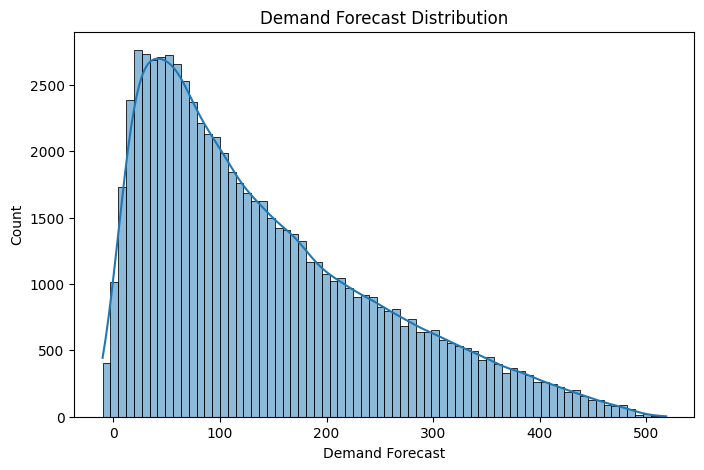

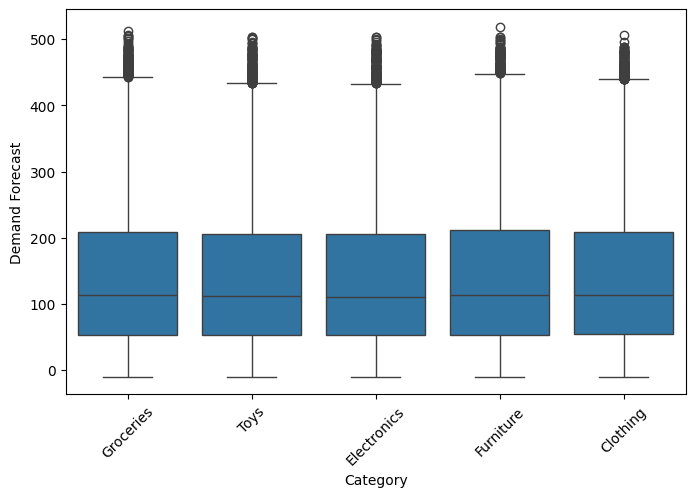

In [ ]:
#exploratory data analysis
plt.figure(figsize=(8,5))
sns.histplot(df['Demand Forecast'], kde=True)
plt.title("Demand Forecast Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Category',
    y='Demand Forecast',
    data=df
)
plt.xticks(rotation=45)
plt.show()

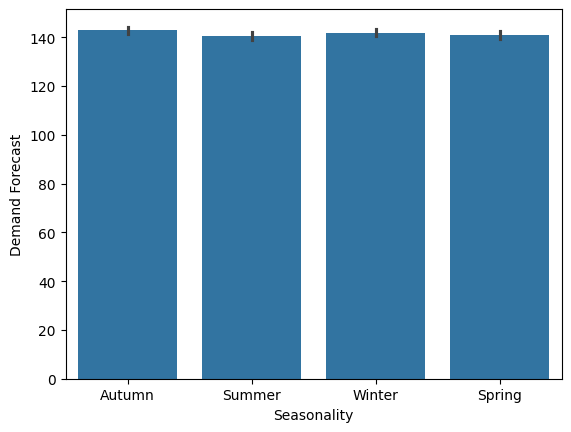

In [ ]:
sns.barplot(
    x='Seasonality',
    y='Demand Forecast',
    data=df
)
plt.show()

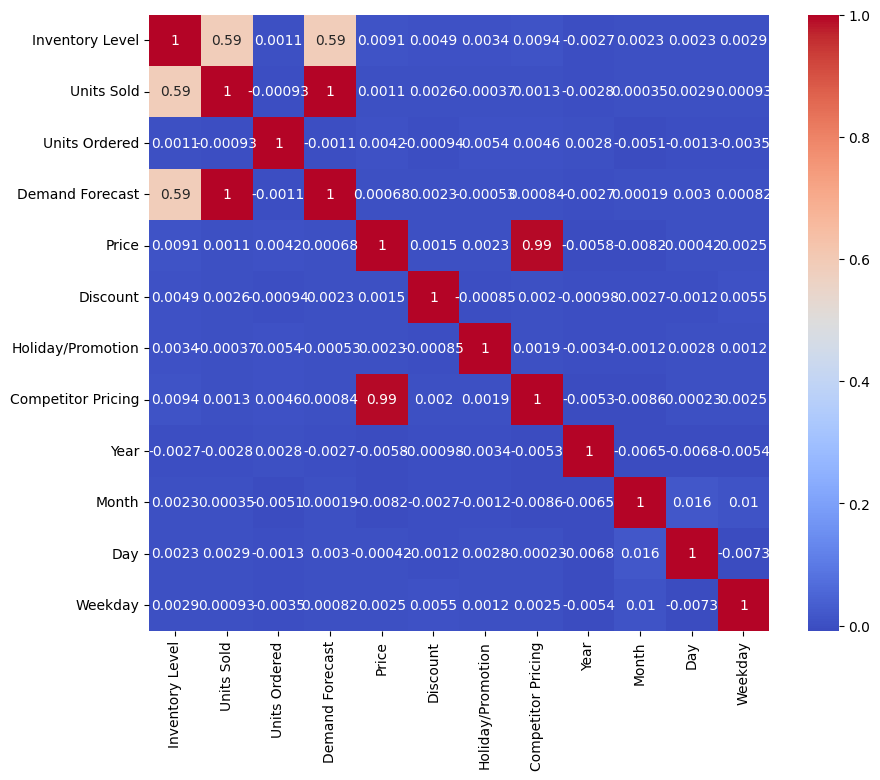

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
#feature engineering
encoder = LabelEncoder()

cat_cols = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality'
]

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
#select feature
y = df['Demand Forecast']

In [ ]:
X = df.drop(
    ['Demand Forecast','Date'],
    axis=1
)

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#model 1 linear regression
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [ ]:
print("MAE:",                        #evulation
      mean_absolute_error(y_test,pred_lr))

print("RMSE:",
      np.sqrt(
          mean_squared_error(y_test,pred_lr)
      ))

print("R2:",
      r2_score(y_test,pred_lr))

MAE: 7.471643920827646
RMSE: 8.648605448025581
R2: 0.9937251639468047


In [ ]:
#model 2 rendom forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [ ]:
#evualtion
print("MAE:",
      mean_absolute_error(y_test,pred_rf))

print("RMSE:",
      np.sqrt(
          mean_squared_error(y_test,pred_rf)
      ))

print("R2:",
      r2_score(y_test,pred_rf))

MAE: 7.542163505471957
RMSE: 8.800518279271271
R2: 0.9935027928729198


In [ ]:
#Model 3  Gradient Boosting
gb = GradientBoostingRegressor()

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

In [ ]:
#Evaluation:
print("MAE:",
      mean_absolute_error(y_test,pred_gb))

print("RMSE:",
      np.sqrt(
          mean_squared_error(y_test,pred_gb)
      ))

print("R2:",
      r2_score(y_test,pred_gb))

MAE: 7.4955289388581265
RMSE: 8.705705529877283
R2: 0.9936420346092615


In [ ]:
#comparing models
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Random Forest',
'Gradient Boosting'
],

'R2':[
r2_score(y_test,pred_lr),
r2_score(y_test,pred_rf),
r2_score(y_test,pred_gb)
]

})

print(results)

               Model        R2
0  Linear Regression  0.993725
1      Random Forest  0.993503
2  Gradient Boosting  0.993642


In [ ]:
#Feature Importance
importance = pd.DataFrame({

'Feature':X.columns,
'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

               Feature  Importance
5           Units Sold    0.993952
4      Inventory Level    0.000771
6        Units Ordered    0.000738
15                 Day    0.000576
11  Competitor Pricing    0.000558
7                Price    0.000553
1           Product ID    0.000516
14               Month    0.000422
16             Weekday    0.000318
0             Store ID    0.000257


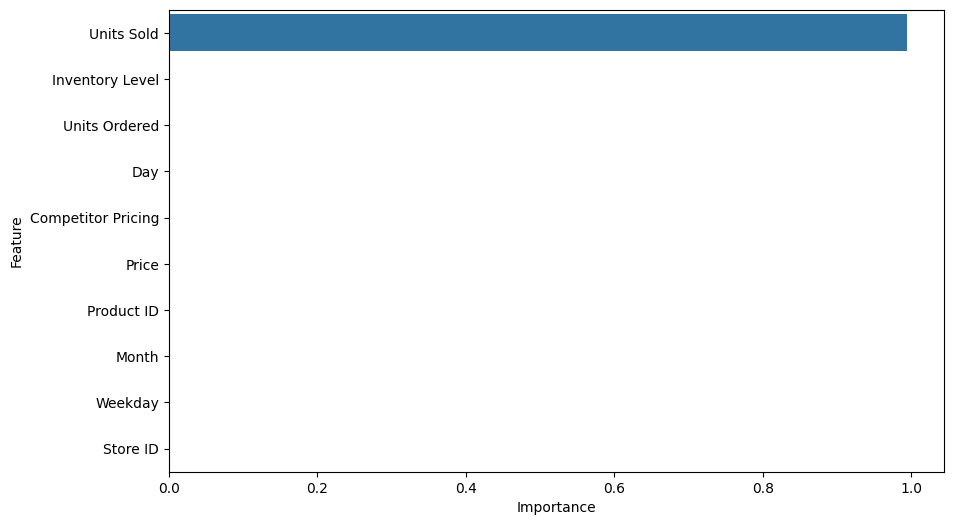

In [ ]:
#Visualization:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

#Inventory Optimization Module

In [ ]:

#Reorder Point Formula
df['Recommended Stock'] = (
    df['Demand Forecast'] * 1.2
)

In [ ]:
#Stock Status
def stock_status(row):

    if row['Inventory Level'] < row['Demand Forecast']:
        return "Reorder"

    elif row['Inventory Level'] > row['Demand Forecast']*1.5:
        return "Overstock"

    else:
        return "Optimal"

df['Stock Status'] = df.apply(
    stock_status,
    axis=1
)

#Business Dashboard Output

In [ ]:
print(
df[['Inventory Level',
'Demand Forecast',
'Recommended Stock',
'Stock Status']].head()
)

   Inventory Level  Demand Forecast  Recommended Stock Stock Status
0              231           135.47            162.564    Overstock
1              204           144.04            172.848      Optimal
2              102            74.02             88.824      Optimal
3              469            62.18             74.616    Overstock
4              166             9.26             11.112    Overstock


#Results Section for Report